<a href="https://colab.research.google.com/github/Yuvraj6085/cnnpro/blob/main/dogVScat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import requests

In [3]:
API_KEY = "52854155-0c17c21638c360c3d41a4aab2"   # Replace with your Pixabay API key
BASE_DIR = "dataset"               # Or use Google Drive path
CLASSES = ["cat", "dog"]         # Classes for the dataset
IMAGES_PER_CLASS = 50              # Total images per class
TRAIN_RATIO = 0.8

In [4]:
for split in ["train", "test"]:
    for cls in CLASSES:
        path = os.path.join(BASE_DIR, split, cls)
        os.makedirs(path, exist_ok=True)

In [5]:
# Function to download images from Pixabay
def download_images(query, save_dir, count):
    print(f"Downloading {count} images for '{query}'...")
    per_page = 20
    downloaded = 0
    page = 1

    while downloaded < count:
        url = f"https://pixabay.com/api/?key={API_KEY}&q={query}&image_type=photo&per_page={per_page}&page={page}"
        response = requests.get(url)
        data = response.json()
        hits = data.get("hits", [])

        if not hits:
            print(f"No more images found for {query}")
            break

        for img in hits:
            if downloaded >= count:
                break
            img_url = img["largeImageURL"]
            try:
                img_data = requests.get(img_url).content
                with open(os.path.join(save_dir, f"{query}_{downloaded+1}.jpg"), "wb") as f:
                    f.write(img_data)
                downloaded += 1
            except Exception as e:
                print(f"Failed to download {img_url}: {e}")

        page += 1

In [6]:
for cls in CLASSES:
    train_count = int(IMAGES_PER_CLASS * TRAIN_RATIO)
    test_count = IMAGES_PER_CLASS - train_count

    train_dir = os.path.join(BASE_DIR, "train", cls)
    test_dir = os.path.join(BASE_DIR, "test", cls)

    download_images(cls, train_dir, train_count)
    download_images(cls, test_dir, test_count)

print("Download complete! Dataset is ready.")

Download complete! Dataset is ready.


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam


In [8]:
IMG_SIZE=(150,150)
BATCH_SIZE=16

In [9]:
train_datagen=ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)

In [10]:
train_datagen=ImageDataGenerator(
    rescale=1./255)

In [12]:
train_generator = train_datagen.flow_from_directory(
    os.path.join(BASE_DIR, "train"),
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 80 images belonging to 2 classes.


In [13]:
test_generator = train_datagen.flow_from_directory(
    os.path.join(BASE_DIR, "test"),
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 20 images belonging to 2 classes.


In [14]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
base_model.trainable = False

/tmp/ipython-input-3568296336.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [15]:
x=base_model.output
x=GlobalAveragePooling2D()(x)
x=Dense(128,activation='relu')(x)
x=Dropout(0.2)(x)


In [16]:
predictons=Dense(1,activation='sigmoid')(x)

In [18]:
from tensorflow.keras.models import Model

model=Model(inputs=base_model.input,outputs=predictons)

In [19]:
model.compile(optimizer=Adam(learning_rate=0.0001),loss='binary_crossentropy',metrics=['accuracy'])

In [20]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [21]:
history=model.fit(
    train_generator,validation_data=test_generator,epochs=10)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.2719 - loss: 1.2728 - val_accuracy: 0.5500 - val_loss: 0.6760
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 690ms/step - accuracy: 0.4734 - loss: 0.8753 - val_accuracy: 0.6500 - val_loss: 0.5930
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.6141 - loss: 0.6464 - val_accuracy: 0.6500 - val_loss: 0.5330
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.6604 - loss: 0.5492 - val_accuracy: 0.7500 - val_loss: 0.4685
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 697ms/step - accuracy: 0.7172 - loss: 0.5132 - val_accuracy: 0.8500 - val_loss: 0.3944
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 681ms/step - accuracy: 0.7547 - loss: 0.4347 - val_accuracy: 0.9000 - val_loss: 0.3278
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.9021 - loss: 0.3152 - val_accuracy: 0.9000 - val_loss: 0.2898
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 774ms/step - accuracy: 0.8156 - loss: 0.3763 - val_accuracy: 0.9500 - val_loss: 0.2437
Epo

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Prediction: Dog


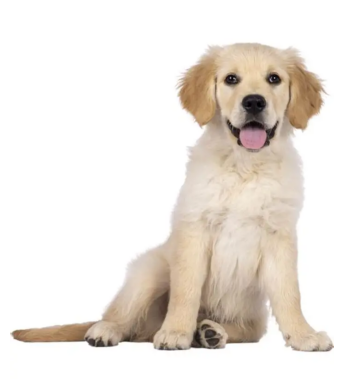

In [24]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Make sure your model is already loaded as `model`

def predict_image(img_path):
    # Open image
    img = Image.open(img_path).convert("RGB")

    # Resize to model input size
    img_resized = img.resize((150,150))

    # Convert to array and normalize
    img_array = image.img_to_array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    pred = model.predict(img_array)[0][0]
    if pred > 0.5:
        print("Prediction: Dog")
    else:
        print("Prediction: Cat")

    # Display image
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# Example usage: replace with your downloaded image path
predict_image("/content/d3.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Prediction: Cat


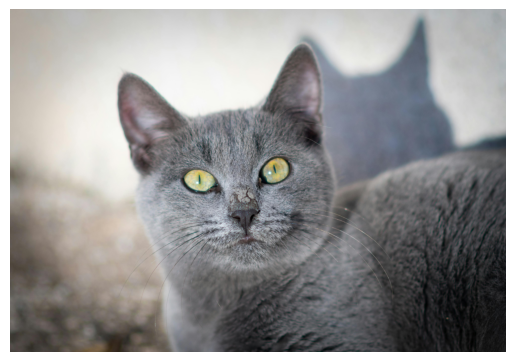

In [25]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Make sure your model is already loaded as `model`

def predict_image(img_path):
    # Open image
    img = Image.open(img_path).convert("RGB")

    # Resize to model input size
    img_resized = img.resize((150,150))

    # Convert to array and normalize
    img_array = image.img_to_array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    pred = model.predict(img_array)[0][0]
    if pred > 0.5:
        print("Prediction: Dog")
    else:
        print("Prediction: Cat")

    # Display image
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# Example usage: replace with your downloaded image path
predict_image("/content/d1.jpg")
